In [1]:
# Libraries
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# Figure formatting
sns.set_style("whitegrid")
sns.set_palette("Set2")

---
## 1. Data Collection / Preparation


We first start off by pulling the API from Skinport.com, where the original file was given to us in `skinport_items.json`. We convert over to `skinport_items.csv`, for easier handling. Print the first few rows to see what columns we are working with, and select only useful data

---

In [ ]:
# JSON taken from saving https://api.skinport.com/v1/sales/history?currency=USD

df = pd.read_json('data/skinport_items.json')
df.to_csv('data/skinport_items.csv', index=False)

# Identify the columns we want to keep
print(df.head())
print(df.columns) 




                             market_hash_name version currency  \
0  Sticker Slab | BIG (Gold) | Stockholm 2021     NaN      USD   
1  Sticker Slab | Kvik (Foil) | Katowice 2019     NaN      USD   
2         Sticker Slab | B1ad3 | Cologne 2015     NaN      USD   
3                   Sticker Slab | Pocket BBQ     NaN      USD   
4          Sticker Slab | oSee | Antwerp 2022     NaN      USD   

                                           item_page  \
0  https://skinport.com/item/sticker-slab-big-gol...   
1  https://skinport.com/item/sticker-slab-kvik-fo...   
2  https://skinport.com/item/sticker-slab-b1ad3-c...   
3  https://skinport.com/item/sticker-slab-pocket-bbq   
4  https://skinport.com/item/sticker-slab-osee-an...   

                                         market_page  \
0  https://skinport.com/market?item=BIG%20(Gold)%...   
1  https://skinport.com/market?item=Kvik%20(Foil)...   
2  https://skinport.com/market?item=B1ad3%20%7C%2...   
3  https://skinport.com/market?item=Pocket

---

# 1.1 Selecting Columns 

From the list of columns we have a total of 9 columns, `'market_hash_name', 'version', 'currency', 'item_page', 'market_page', 'last_24_hours', 'last_7_days', 'last_30_days', 'last_90_days'`. From, an initial glance, we can see that `'item_page'` and `'market_page'` are columns that link to a specific items store page, since we are interested in doing analysis on quantifiable data, we can drop those two columns. We are also only interested in the data of weapon skins for the past month (30 day), so we can drop all other time variables.

---

In [ ]:
#Creating a temporary cleaned data frame with only columns we want to keep for analysis
df_cleaned_temp = df.drop(columns=[
    "item_page",
    "market_page",
    "last_24_hours",
    "last_7_days",
    "last_90_days"
])

print(df_cleaned_temp.shape)
df_cleaned_temp.head()

(33855, 4)


,market_hash_name,version,currency,last_30_days
0,Sticker Slab | BIG (Gold) | Stockholm 2021,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."
1,Sticker Slab | Kvik (Foil) | Katowice 2019,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."
2,Sticker Slab | B1ad3 | Cologne 2015,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."
3,Sticker Slab | Pocket BBQ,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."
4,Sticker Slab | oSee | Antwerp 2022,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."


---

Notice that `'last_30_days'` is a dictionary containing `'min'`, `'max'`, `'avg'`, `'median'`, `'volume'`. We can extract this out into columns for our cleaned data frame.

---

In [ ]:
last_30_days = pd.json_normalize(df['last_30_days']) # expand the dictionary of last_30_days into a temporary data frame

df_cleaned_temp = df_cleaned_temp.join(last_30_days)
df_cleaned_temp = df_cleaned_temp.drop(columns='last_30_days')

df_cleaned_temp.head()

,market_hash_name,version,currency,min,max,avg,median,volume
0,Sticker Slab | BIG (Gold) | Stockholm 2021,NaN,USD,NaN,NaN,NaN,NaN,0
1,Sticker Slab | Kvik (Foil) | Katowice 2019,NaN,USD,NaN,NaN,NaN,NaN,0
2,Sticker Slab | B1ad3 | Cologne 2015,NaN,USD,NaN,NaN,NaN,NaN,0
3,Sticker Slab | Pocket BBQ,NaN,USD,NaN,NaN,NaN,NaN,0
4,Sticker Slab | oSee | Antwerp 2022,NaN,USD,NaN,NaN,NaN,NaN,0


---

Next check for missing data 

---

                  Missing Values  Percent Missing
market_hash_name               0         0.000000
version                    32889        97.146655
currency                       0         0.000000
min                        16205        47.865899
max                        16205        47.865899
avg                        16205        47.865899
median                     16205        47.865899
volume                         0         0.000000


<Axes: >

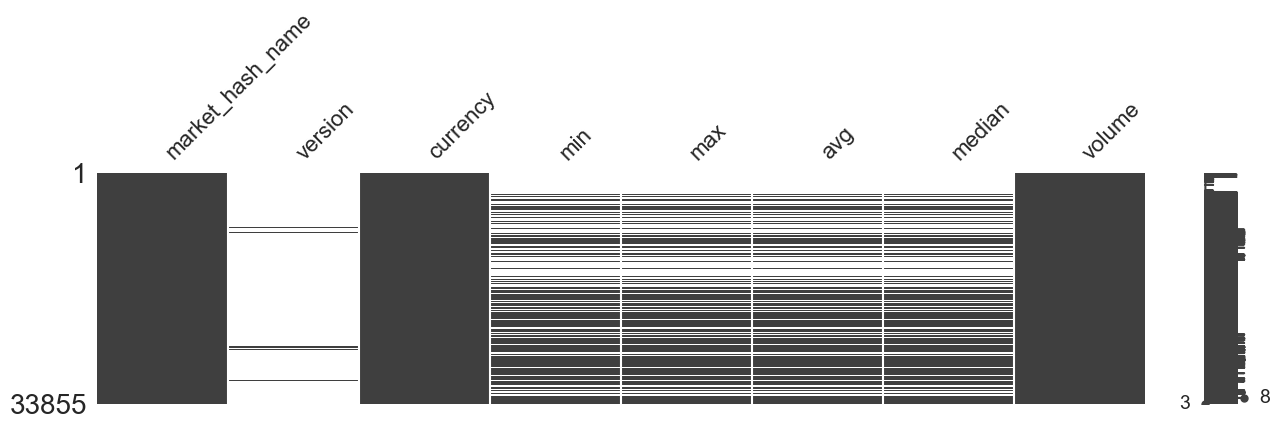

In [ ]:
missing_table = pd.DataFrame({
        'Missing Values': df_cleaned_temp.isna().sum(), 
        'Percent Missing': df_cleaned_temp.isna().mean() * 100
    })

print(missing_table)


# We can visualize the missing data with missingno
msno.matrix(df_cleaned_temp, figsize=(15, 3)) 

---

Note: All the missing data seems to be all from the same entries, so we will remove rows where every statistic is missing

---

In [ ]:
# Remove rows where every statistic is missing
df_cleaned_temp = df_cleaned_temp.dropna(subset=["min", "max", "avg", "median"], how="all") # version is not dropped as None *is* a valid version rather than representing null

new_missing_table = pd.DataFrame({
        'Missing Values': df_cleaned_temp.isna().sum(), 
        'Percent Missing': df_cleaned_temp.isna().mean() * 100
    })

print(new_missing_table)
print(df_cleaned_temp.shape) # removed exactly 16205 entires, as expected
df_cleaned_temp.head()

                  Missing Values  Percent Missing
market_hash_name               0         0.000000
version                    17251        97.739377
currency                       0         0.000000
min                            0         0.000000
max                            0         0.000000
avg                            0         0.000000
median                         0         0.000000
volume                         0         0.000000
(17650, 8)


,market_hash_name,version,currency,min,max,avg,median,volume
210,Souvenir AK-47 | Steel Delta (Field-Tested),NaN,USD,4.06,8.61,5.35,4.87,7
332,Souvenir XM1014 | Hieroglyph (Factory New),NaN,USD,0.56,1.20,0.99,1.04,6
343,Souvenir MAG-7 | Copper Coated (Field-Tested),NaN,USD,0.35,1.16,0.59,0.44,4
580,Souvenir P90 | ScaraB Rush (Well-Worn),NaN,USD,4.92,4.92,4.92,4.92,1
2795,AK-47 | Black Laminate (Well-Worn),NaN,USD,58.03,58.03,58.03,58.03,1


---

From `'market_hash_name'` we get a lot of information regarding a specific skin that can affect it's pricing, such as `Souvenir` status,  `StatTrak™` status, `skin names` and item `condition`. We can break `market_hash_name` into seperate categorical variables. 

We also want to look at the most common used weapons in the game, as those weapons have more "value" due to popularity, so we filter by those weapons, which would include the `AK-47`, `M4A1-S`, `M4A4`, and `AWP`.

---

In [ ]:
# create new columns souvenir and stat_trak

df_cleaned_temp["souvenir"] = df_cleaned_temp["market_hash_name"].str.contains("Souvenir")
df_cleaned_temp["stat_trak"] = df_cleaned_temp["market_hash_name"].str.contains("StatTrak")

#filtering 4 most popular guns for analysis

temp_df = df_cleaned_temp[df_cleaned_temp["market_hash_name"].str.contains("AK-47|M4A1-S|M4A4|AWP")]

temp_df.head()
df_cleaned = temp_df
df_cleaned.head()

,market_hash_name,version,currency,min,max,avg,median,volume,souvenir,stat_trak
210,Souvenir AK-47 | Steel Delta (Field-Tested),NaN,USD,4.06,8.61,5.35,4.87,7,True,False
2795,AK-47 | Black Laminate (Well-Worn),NaN,USD,58.03,58.03,58.03,58.03,1,False,False
2813,AK-47 | Aquamarine Revenge (Battle-Scarred),NaN,USD,27.33,35.98,32.02,31.67,7,False,False
2814,AK-47 | Fire Serpent (Factory New),NaN,USD,2485.40,2625.52,2555.46,2555.46,2,False,False
2908,AK-47 | Predator (Battle-Scarred),NaN,USD,9.23,9.68,9.46,9.45,2,False,False


---

We can now break apart `'market_has_name'` into seperate variables (`weapon`, `skin_name`, `condition`).

---

In [ ]:
# seperate market hash name into different variables
df_cleaned[['weapon', 'skin_name', 'condition']] = df_cleaned['market_hash_name'].str.extract(r'(.+?)\s*\|\s*(.+?)\s*\((.+?)\)', expand=True)

# embellishments (souvenir, stattrak) are unecessary to remove because we will filter weapon types through .contains() anyways

df_cleaned=df_cleaned.drop(columns='market_hash_name')
df_cleaned.head()

,version,currency,min,max,avg,median,volume,souvenir,stat_trak,weapon,skin_name,condition
210,NaN,USD,4.06,8.61,5.35,4.87,7,True,False,Souvenir AK-47,Steel Delta,Field-Tested
2795,NaN,USD,58.03,58.03,58.03,58.03,1,False,False,AK-47,Black Laminate,Well-Worn
2813,NaN,USD,27.33,35.98,32.02,31.67,7,False,False,AK-47,Aquamarine Revenge,Battle-Scarred
2814,NaN,USD,2485.40,2625.52,2555.46,2555.46,2,False,False,AK-47,Fire Serpent,Factory New
2908,NaN,USD,9.23,9.68,9.46,9.45,2,False,False,AK-47,Predator,Battle-Scarred


---

Reorder Columns for better readability.

---

In [ ]:
# Remove souvenir / StatTrak from weapon names since we already have tuples categories
df_cleaned['weapon'] = df_cleaned['weapon'].str.replace(
    r"(Souvenir\s+|StatTrak™?\s+)",
    "",
    regex=True
).str.strip()

#Reordering columns for better readability
first_cols = ["weapon", "skin_name", "condition"]
other_cols = [col for col in df_cleaned.columns if col not in first_cols]

df_cleaned = df_cleaned[first_cols + other_cols]

df_cleaned.head()

,weapon,skin_name,condition,version,currency,min,max,avg,median,volume,souvenir,stat_trak
210,AK-47,Steel Delta,Field-Tested,NaN,USD,4.06,8.61,5.35,4.87,7,True,False
2795,AK-47,Black Laminate,Well-Worn,NaN,USD,58.03,58.03,58.03,58.03,1,False,False
2813,AK-47,Aquamarine Revenge,Battle-Scarred,NaN,USD,27.33,35.98,32.02,31.67,7,False,False
2814,AK-47,Fire Serpent,Factory New,NaN,USD,2485.40,2625.52,2555.46,2555.46,2,False,False
2908,AK-47,Predator,Battle-Scarred,NaN,USD,9.23,9.68,9.46,9.45,2,False,False


---

For analysis we typically want quantifiable variables and numeric values. In Counter-Strike 2, weapon conditions can affect a skins price, so we can assign corresponding condition values to every possible weapon condition. Since we are converting character values into numeric variables, we might as well convert our boolean variables `'souvenir'` and `'stat_trak'` into binary values for easier analysis as well.

---

In [ ]:
# Convert souvenir and stat_trak boolean status to binary for regression purposes
df_cleaned["souvenir"] = df_cleaned["souvenir"].astype(int)
df_cleaned["stat_trak"] = df_cleaned["stat_trak"].astype(int)


# map values to condition for linear regression purposes
condition_codes = {
    "Factory New": 4, 
    "Minimal Wear": 3, 
    "Field-Tested": 2,
    "Well-Worn": 1, 
    "Battle-Scarred": 0,
}

# recode age categories
df_cleaned_enc = df_cleaned.replace({'condition': condition_codes})

df = df_cleaned_enc

df.head()

,weapon,skin_name,condition,version,currency,min,max,avg,median,volume,souvenir,stat_trak
210,AK-47,Steel Delta,2,NaN,USD,4.06,8.61,5.35,4.87,7,1,0
2795,AK-47,Black Laminate,1,NaN,USD,58.03,58.03,58.03,58.03,1,0,0
2813,AK-47,Aquamarine Revenge,0,NaN,USD,27.33,35.98,32.02,31.67,7,0,0
2814,AK-47,Fire Serpent,4,NaN,USD,2485.40,2625.52,2555.46,2555.46,2,0,0
2908,AK-47,Predator,0,NaN,USD,9.23,9.68,9.46,9.45,2,0,0


---

Now we have the completed cleaned our data for analysis, we can convert it into a csv file(`skinport_items_cleaned(1).csv`) for others to use.

---

In [ ]:
# write to csv for others to use

df.to_csv('data/skinport_items_cleaned(1).csv', index=False)

In [ ]:
df["price_tier"] = pd.qcut(
    df["avg"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

df.head()

,weapon,skin_name,condition,version,currency,min,max,avg,median,volume,souvenir,stat_trak,price_tier
210,AK-47,Steel Delta,2,NaN,USD,4.06,8.61,5.35,4.87,7,1,0,Low
2795,AK-47,Black Laminate,1,NaN,USD,58.03,58.03,58.03,58.03,1,0,0,Medium-High
2813,AK-47,Aquamarine Revenge,0,NaN,USD,27.33,35.98,32.02,31.67,7,0,0,Medium-Low
2814,AK-47,Fire Serpent,4,NaN,USD,2485.40,2625.52,2555.46,2555.46,2,0,0,High
2908,AK-47,Predator,0,NaN,USD,9.23,9.68,9.46,9.45,2,0,0,Medium-Low


---

## 2. Data Visualization 

With the cleaned data frame, we can now look into visualizing the data for each of our weapon.

---

For a quick intial look into our data, we take a look into the counts of the weapons, and remove any unwanted columns

In [ ]:
df['weapon'].value_counts()

weapon
AK-47              455
M4A4               347
AWP                339
M4A1-S             314
Sealed Graffiti      3
Sticker              1
Name: count, dtype: int64

## 2.1 Histograms

---

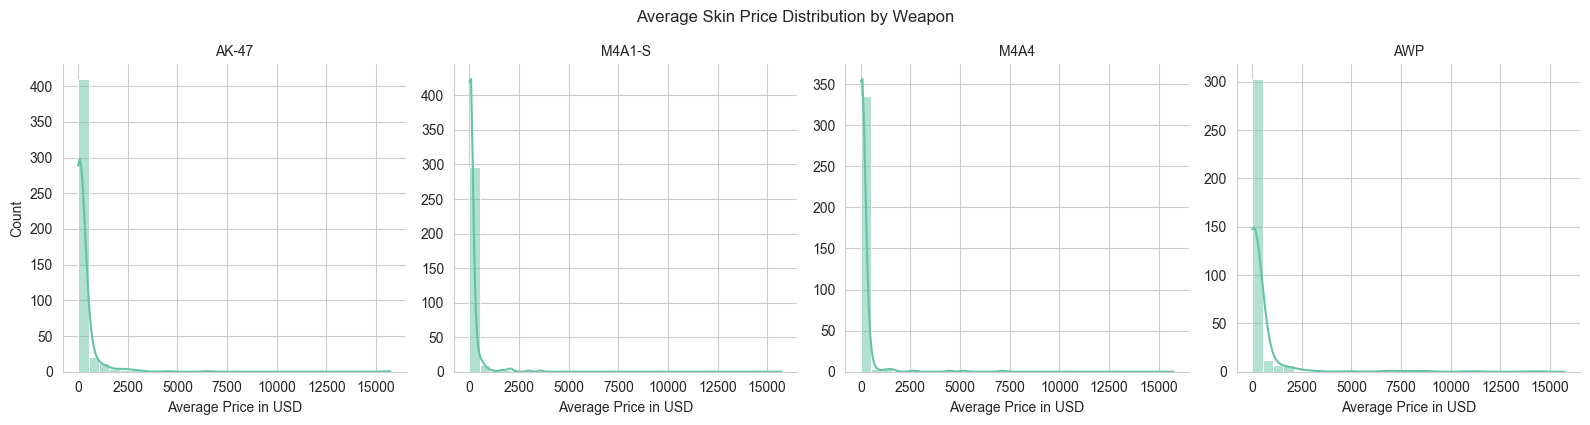

weapon
AK-47     12.04
AWP        6.89
M4A1-S     5.77
M4A4       9.06
Name: avg, dtype: float64

In [ ]:
# Keep only the 4 weapon categories
weapon_order = ["AK-47", "M4A1-S", "M4A4", "AWP"]
df_weapons = df[df["weapon"].isin(weapon_order)].copy()

# Make sure avg is numeric
df_weapons["avg"] = pd.to_numeric(df_weapons["avg"], errors="coerce")

# Remove missing avg values
df_weapons = df_weapons.dropna(subset=["avg"])

# Raw histogram by weapon
g = sns.displot(
    data=df_weapons,
    x="avg",
    col="weapon",
    col_order=weapon_order,
    bins=30,
    kde=True,
    height=4,
    aspect=1,
    facet_kws={"sharex": True, "sharey": False}
)

g.set_axis_labels("Average Price in USD", "Count")
g.set_titles("{col_name}")
g.fig.suptitle("Average Skin Price Distribution by Weapon", y=1.05)

plt.show()
df_weapons.groupby("weapon")["avg"].skew().round(2)

---

Here we can see that the raw histogram shows that average skin prices are highly right-skewed, where majority of skin are concentrated around lower price points. This makes sense, as Counter Strike's skin market is notoriously known for its high weapon skin prices, like the AWP Dragon Lore, being priced around $11,000. For our purposes of visualizing the data, we can appply a log transformation to `'avg'`

---

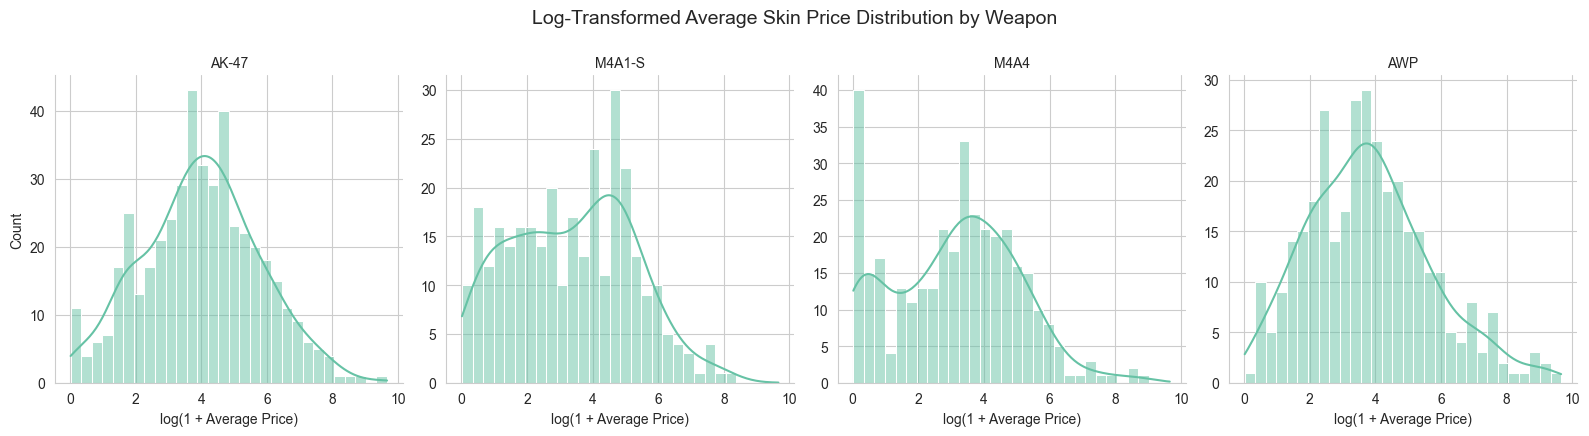

In [ ]:
# Create log-transformed avg column
df_weapons["log_avg"] = np.log1p(df_weapons["avg"])

# log_avg histogram
g = sns.displot(
    data=df_weapons,
    x="log_avg",
    col="weapon",
    col_order=weapon_order,
    bins=30,
    kde=True,
    height=4,
    aspect=1,
    facet_kws={"sharex": True, "sharey": False}
)

g.set_axis_labels("log(1 + Average Price)", "Count")
g.set_titles("{col_name}")

g.fig.suptitle(
    "Log-Transformed Average Skin Price Distribution by Weapon",
    y=1.08,
    fontsize=14
)

plt.show()

---

We can see that there is kind of an interesting pattern. For context, the game is separated into two teams; Terrorist (T) and Counter-Terrorist (CT), with the AK-47, M4A1-S, M4A4, and the AWP being "primary" weapons. There is nuance, in the fact that there are other weapons within the game, but for the majority of players, these weapons define the game.

What is interesting is the price distributions for the M4A1-S and M4A4. The M4A1-S and M4A4 are CT sided weapons only, where the restriction is that they do not have the ability to one shot an opponent. Contrary to the AK47, which is the only primary weapon for the T side. The AWP is its own separate "rifle" in the manner that it is a sniper rifle, but can be equipped on both sides.

The distributions for the average AK-47 and AWP prices follow an approximate bell curve. In contrast, the M4A1-S and the M4A4 show more tendencies to sell at lower-price points.

These trends could probably be explained by the fact that the AK-47 being the only "primary" weapon for the T side. While the M4A1-S and M4A4 are two options CT players can choose from, where both weapons are of equal popularity, selling them might be more difficult. The AWP can be explained as it is the only sniper rifle in the game that can one-shot enemy opponents.

---

## 2.2 Boxplots

---

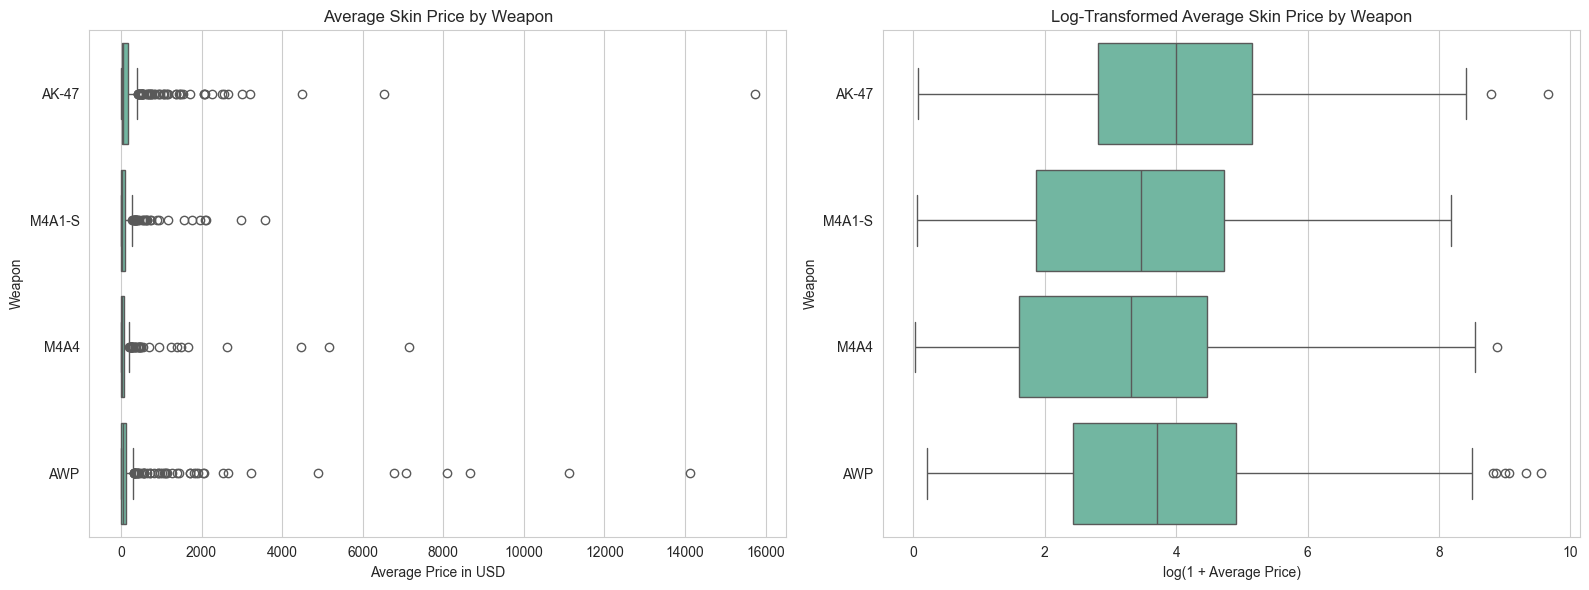

In [ ]:
# Side-by-side box plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw average price
sns.boxplot(
    data=df_weapons,
    x="avg",
    y="weapon",
    order=weapon_order,
    ax=axes[0]
)

axes[0].set_title("Average Skin Price by Weapon")
axes[0].set_xlabel("Average Price in USD")
axes[0].set_ylabel("Weapon")

# Log-transformed average price
sns.boxplot(
    data=df_weapons,
    x="log_avg",
    y="weapon",
    order=weapon_order,
    ax=axes[1]
)

axes[1].set_title("Log-Transformed Average Skin Price by Weapon")
axes[1].set_xlabel("log(1 + Average Price)")
axes[1].set_ylabel("Weapon")

plt.tight_layout()
plt.show()


With the boxplots, we are able to look visualize the the weapon skin outliers. Here we can see that the AWP has the most average price outliers. The maximum value out of all the weapon seems to be for the AK-47. However, since Skinport is a community based market, it could just be a seller over-valuing their item.

## Summary statistics

In [ ]:
# quick overview of numeric variables

df[['min', 'max', 'avg', 'median', 'volume']].describe().round(2)

,min,max,avg,median,volume
count,1469.00,1469.00,1469.00,1469.00,1469.00
mean,203.80,268.96,224.86,221.89,40.58
std,862.19,925.73,888.34,887.45,71.79
min,0.02,0.03,0.02,0.02,1.00
25%,5.75,13.22,7.79,7.49,4.00
50%,29.04,54.93,36.40,35.33,13.00
75%,101.19,176.42,121.22,117.36,44.00
max,15726.81,15726.81,15726.81,15726.81,768.00


## Average price by condition

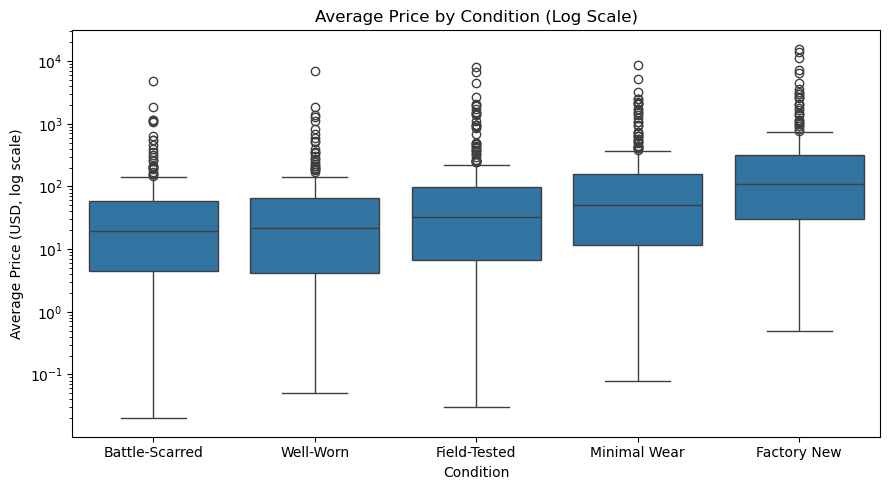

In [ ]:
condition_labels = {'0': 'Battle-Scarred', '1': 'Well-Worn', '2': 'Field-Tested', '3': 'Minimal Wear', '4': 'Factory New'}
df['condition_label'] = df['condition'].map(condition_labels)
df = df.dropna(subset=['condition_label'])
cond_order = ['Battle-Scarred', 'Well-Worn', 'Field-Tested', 'Minimal Wear', 'Factory New']

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='condition_label', y='avg', order=cond_order, ax=ax)
ax.set_yscale('log')
ax.set_title('Average Price by Condition (Log Scale)')
ax.set_xlabel('Condition')
ax.set_ylabel('Average Price (USD, log scale)')
plt.tight_layout()
plt.show()

## Price Premium: StatTrak™ and Souvenir

StatTrak™ skins track kill counts and typically sell at a premium. Souvenir skins are tournament drops and tend to have different pricing dynamics. We compare median average prices across these categories.

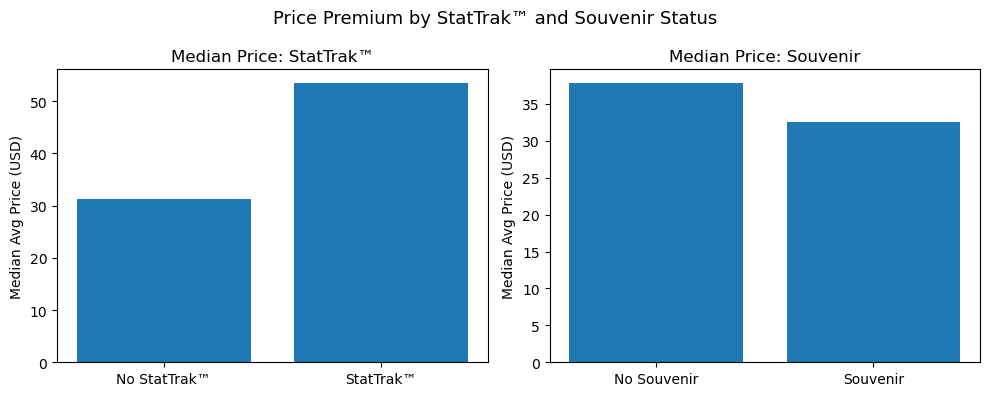

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, label in zip(axes, ['stat_trak', 'souvenir'], ['StatTrak™', 'Souvenir']):
    medians = df.groupby(col)['avg'].median()
    ax.bar([f'No {label}', label], [medians.get(0, 0), medians.get(1, 0)])
    ax.set_title(f'Median Price: {label}')
    ax.set_ylabel('Median Avg Price (USD)')

plt.suptitle('Price Premium by StatTrak™ and Souvenir Status', fontsize=13)
plt.tight_layout()
plt.show()

## Sales Volume by Weapon

Sales volume reflects market liquidity. Higher volume indicates more actively traded skins.

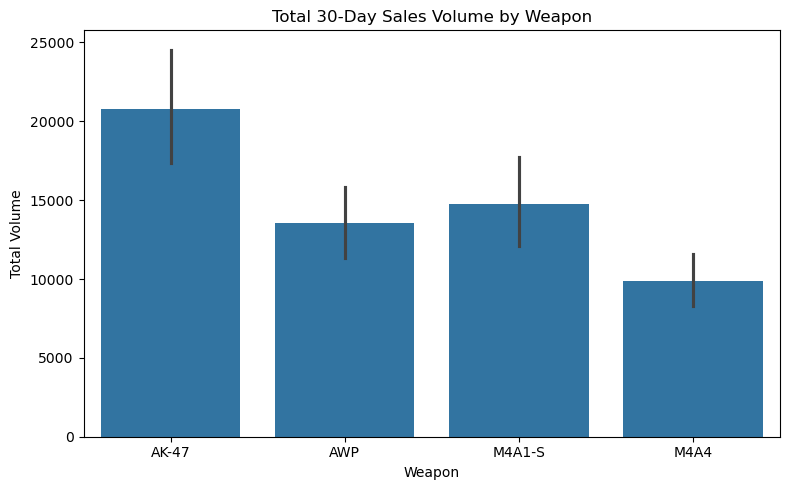

In [ ]:
weapon_order = df.groupby('weapon')['avg'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x='weapon', y='volume', order=weapon_order,
            estimator='sum', ax=ax)
ax.set_title('Total 30-Day Sales Volume by Weapon')
ax.set_xlabel('Weapon')
ax.set_ylabel('Total Volume')
plt.tight_layout()
plt.show()

## Correlation Heatmap

We examine pairwise correlations among numeric variables. Strong correlation between `min`, `max`, `avg`, and `median` is expected. The relationship between `condition` and price is of primary interest.

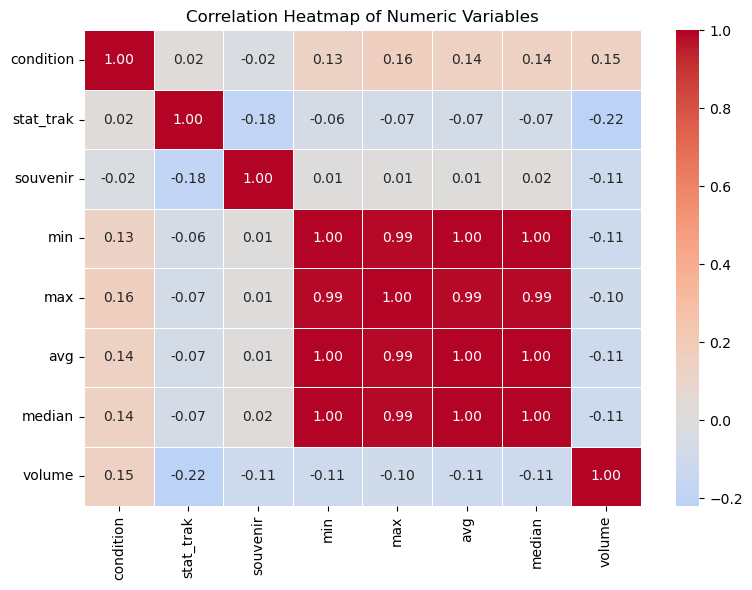

In [ ]:
numeric_cols = ['condition', 'stat_trak', 'souvenir', 'min', 'max', 'avg', 'median', 'volume']
corr = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

## Top 10 Most Expensive Skins

We identify the ten skins with the highest median average price over the past 30 days.

In [ ]:
top10 = (
    df.groupby(['weapon', 'skin'])['avg']
    .median()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top10.columns = ['Weapon', 'Skin', 'Median Avg Price (USD)']
top10['Median Avg Price (USD)'] = top10['Median Avg Price (USD)'].round(2)
top10

,Weapon,Skin,Median Avg Price (USD)
0,AK-47,Wild Lotus,15726.81
1,AWP,Gungnir,8099.76
2,AWP,Dragon Lore,7729.65
3,M4A4,Howl,5172.45
4,M4A1-S,Knight,2984.14
5,AWP,The Prince,2627.38
6,AK-47,Hydroponic,2083.46
7,M4A1-S,Hot Rod,2026.25
8,AWP,Medusa,1885.20
9,M4A1-S,Imminent Danger,1767.19
